In [1]:
import pandas as pd
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from torch.utils.data import Dataset

from config import *

In [2]:
test_df = pd.read_csv(TEST_CSV)
test_df.head()

,text,sentiment
0,Its WoW! effect Thanks for the update.,1
1,In a really Good mood for absolutely no reason...,1
2,"Loves the 2nd half of even days, orch and jazz...",1
3,last week and I interviewed and we told him...,1
4,Studio Ghibli for this year; Ponyo! as always...,1


In [3]:
test_reviews = test_df["text"]
test_labels = test_df["sentiment"]

In [5]:
import pickle   
from config import VECTORIZER_PATH

with open(VECTORIZER_PATH, "rb") as f:
    vectorizer = pickle.load(f)

with open("./models/svm_sentiment_model.pkl", "rb") as f:
    svm = pickle.load(f)

X_test = vectorizer.transform(test_reviews)

svm_predictions = svm.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


accuracy = accuracy_score(
    test_labels,
    svm_predictions
)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 68.03%


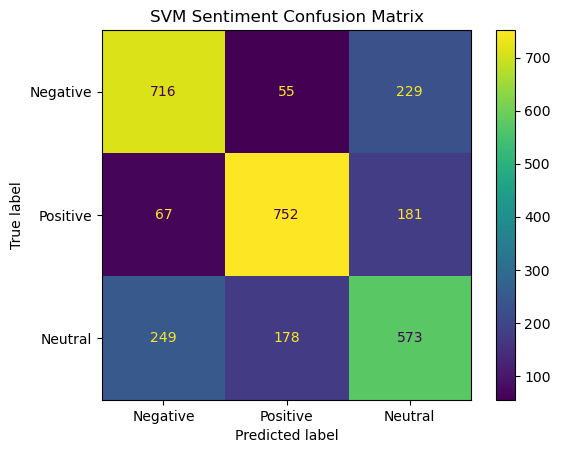

In [9]:
cm = confusion_matrix(
    test_labels,
    svm_predictions
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive",
        "Neutral"
    ]
)

disp.plot()

plt.title("SVM Sentiment Confusion Matrix")
plt.show()

In [10]:
cm

array([[716,  55, 229],
       [ 67, 752, 181],
       [249, 178, 573]], dtype=int64)

In [12]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        svm_predictions,
        target_names=[
            "Negative",
            "Positive",
            "Neutral"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.69      0.72      0.70      1000
    Positive       0.76      0.75      0.76      1000
     Neutral       0.58      0.57      0.58      1000

    accuracy                           0.68      3000
   macro avg       0.68      0.68      0.68      3000
weighted avg       0.68      0.68      0.68      3000



In [ ]:
from config import MODEL_NAME

with open(f"./logs/[{MODEL_NAME}]_log.txt", "a") as f:    
    f.write(f"""\n\n
====================
Testing
====================

Accuracy: {accuracy * 100:.2f}%\n
Confusion Matrix:\n{cm}\n

""")

print("Accuracy added to experiment file")